In [1]:
import os
import sys 
from pyprojroot import here
sys.path.insert(0, str(here()))
from os.path import exists

import geopandas as gpd
from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data
from laos_gggi.data_functions.disaster_point_data import (load_disaster_point_data, 
                    load_synthetic_non_disaster_points, load_grid_point_data, load_non_disaster_grid)

from laos_gggi.plotting import configure_plot_style
from laos_gggi.statistics import get_distance_to_rivers, prediction_to_gpd_df , set_plotting_data, add_data, add_country_effect
from laos_gggi.data_functions.combine_data import load_all_data
from pymc.model.transform.optimization import freeze_dims_and_data

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import arviz as az
import scipy
import nutpie
import pathlib
import pickle
import wbdata
import datetime

import pymc as pm
import pytensor.tensor as pt
from laos_gggi.sample import sample_or_load


from laos_gggi.transformers import Standardize
from laos_gggi.data_functions.world_bank_data_loader import load_wb_data

configure_plot_style()

# Load and prepare data

In [2]:
# Load time series predictions
predictions = pd.read_csv(here('data/climate_forecast_lao.csv'))

In [3]:
world = load_shapefile('world')
# rivers = load_rivers_data()
laos = world.query('ISO_A3 == "LAO"')

# Select SEA shape
laos_neighboors = [
    "KHM",  # Cambodia
    "THA",  # Thailand
    "LAO",  # Laos
    "VNM",  # Vietnam
]

# Define maps
sea_map = world.query('ISO_A3 in @laos_neighboors')
laos_map = world.query('ISO_A3 == "LAO"')

In [4]:
# Create prediction grids
sea_point_grid = load_grid_point_data(region='custom', grid_size=400, 
                            force_reload = False, 
                            iso_list=laos_neighboors,
                           file_reg_name="laos_neighboors_medium" ).rename(columns = {"lon": "long"})

laos_point_grid = load_grid_point_data(region='laos',
                                       grid_size=400, 
                                       force_reload = False,).rename(columns = {"lon": "long"})

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\laos_neighboors_medium_points_400.shp\laos_neighboors_medium_points_400.shp.shp
Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\laos_points_400.shp\laos_points_400.shp.shp


In [5]:
all_data = load_all_data()
panel_data  = all_data["df_panel"][['population_density', 'gdp_per_cap', 'Population', 'precip',]]
co2 = all_data["df_time_series"]["co2"]

In [6]:
########## disasters ##########
disasters = load_disaster_point_data()
#Delimiting data set to hydrometereological disasters
hydro_met_list = ['Hydrological', 'Meteorological']
hydrometereological_disasters = ['Flood', 'Storm', 'Mass movement (wet)']

disasters = disasters.rename(columns ={'Disaster Subgroup': 'subgroup'}).query('subgroup in @hydro_met_list')

disasters = disasters.rename(columns ={'Disaster Type': 'disaster_type'}).query('disaster_type in @hydrometereological_disasters')

########## non-disasters ##########
not_disasters = load_synthetic_non_disaster_points(by='country',
                                                       multiplier=15,
                                                       countries = laos_neighboors , list_name = 'laos_neigh'
                                                    )

# Merge data frames
merged_df = pd.concat([not_disasters.assign(is_disaster = 0), 
                       disasters.reset_index().assign(is_disaster=1)], 
                      ignore_index= True)

# Adjust date format
merged_df["Start_Year"] = pd.to_datetime(merged_df["Start_Year"])

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\synthetic_non_disasters_country_times_15_laos_neigh_.csv


In [7]:
from statsmodels.tsa.seasonal import STL

precipitation = all_data["gpcc"]
precip_deviation = precipitation.groupby('ISO').transform(lambda x: x - x.iloc[:30].mean()).rename(columns={'precip':'precip_deviation'})

df_clim = all_data["df_time_series"][["co2", "Temp", "precip"]].iloc[1:-1].dropna(subset=['Temp'])
trend =  STL(pd.DataFrame(df_clim["Temp"].dropna()), period=3).fit().trend
dev_from_trend_ocean_temp = (df_clim['Temp'] - trend).to_frame(name='dev_ocean_temp')

In [8]:
from functools import reduce
df = reduce(lambda l, r: pd.merge(l, r, left_on=['ISO', 'Start_Year'], right_index=True, how='left'), [merged_df, panel_data, precip_deviation])
df = reduce(lambda l, r: pd.merge(l, r , left_on=['Start_Year'], right_index=True, how='left'), [df, co2, dev_from_trend_ocean_temp])

In [9]:
#Creating log variables
log_list = ["distance_to_river", "distance_to_coastline", "Total_Affected", "Total_Damage_Adjusted", "population_density",
            "gdp_per_cap"]
for y in log_list:
    df[f"log_{y}"] = np.log(df[y])



C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
#Delimiting data set
columns_to_use = ['ISO', 'Start_Year', "is_disaster", 'distance_to_river', 'distance_to_coastline',
               "Population", "co2", "precip_deviation", "dev_ocean_temp", "lat", "long" , "geometry", ]

features = ['log_distance_to_river', 'log_distance_to_coastline',
             "Population", "co2", "precip_deviation", "dev_ocean_temp", 'log_population_density',
             'log_gdp_per_cap', ]

model_df = df[ list( set( columns_to_use).union(set(features)) )].dropna()


In [11]:
# Define list of features standardized
features_stand = []
for feature in features:
    features_stand.append(feature + "__standardized" )

time_varying_features = ['Population','co2','precip_deviation','dev_ocean_temp','log_population_density','log_gdp_per_cap',]
time_varying_features_stand = []

for feature in time_varying_features:
    time_varying_features_stand.append(feature + "__standardized")

### Create SEA and Laos data sets

In [12]:
#Create the geodata set for sea disasters
sea_disasters = model_df.query('ISO in @laos_neighboors & is_disaster == 1')

sea_disasters_geo = gpd.GeoDataFrame(
                sea_disasters,
    geometry=gpd.points_from_xy(sea_disasters["long"], sea_disasters["lat"]), crs="EPSG:4326"
            )

# Create the geodata set for Laos disasters
laos_disasters = model_df.query('ISO == "LAO" & is_disaster == 1')

laos_disasters_geo = gpd.GeoDataFrame(
                laos_disasters,
    geometry=gpd.points_from_xy(laos_disasters["long"], laos_disasters["lat"]), crs="EPSG:4326"
            )

In [13]:
# Filter disasters outside Lao
laos_disasters= laos_disasters.query('log_distance_to_coastline > 4')
laos_disasters_geo= laos_disasters_geo.query('log_distance_to_coastline > 4')

In [14]:
# Define dfs
sea_df = model_df.query('ISO in @laos_neighboors')
lao_df = model_df.query('ISO == "LAO"')

#Tranform dfs to geopandas df
sea_df = gpd.GeoDataFrame(sea_df,  geometry=gpd.points_from_xy(sea_df["long"],
                                sea_df["lat"]),crs="EPSG:4326")

lao_df = gpd.GeoDataFrame(lao_df,  geometry=gpd.points_from_xy(lao_df["long"],
                                lao_df["lat"]),crs="EPSG:4326")

In [15]:
country_year_data ={}
country_year_df = {}
years_data = [2000,2010, 2018]

for year in years_data:
    country_year_data[year] = {}
    country_year_df[year] = pd.DataFrame()
    for country in laos_neighboors:
        country_year_data[year][country] = sea_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
        country_year_df[year] = pd.concat([country_year_df[year], country_year_data[year][country] ])  

C:\Users\camil\AppData\Local\Temp\ipykernel_91220\1094466301.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  country_year_data[year][country] = sea_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
C:\Users\camil\AppData\Local\Temp\ipykernel_91220\1094466301.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  country_year_data[year][country] = sea_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
C:\Users\camil\AppData\Local\Temp\ipykernel_91220\1094466301.py:9: FutureWarni

In [16]:
# Merge points with world ISO
sea_point_grid_extended = {}
sea_point_grid_extended_df = gpd.sjoin(sea_point_grid, sea_map, how="left", )
sea_point_grid_extended_df = sea_point_grid_extended_df.rename(columns = {"lon": "long"})

# Creating the laos_point_grid_extended
laos_point_grid["ISO"] = 'LAO'
laos_point_grid_extended = {}
laos_point_grid_extended_df = gpd.sjoin(laos_point_grid, laos_map, how="left", )
laos_point_grid_extended_df = laos_point_grid_extended_df.rename(columns = {"lon": "long"})

In [17]:
for year in years_data:
    # Region loop
    sea_point_grid_extended[year] = pd.merge(sea_point_grid_extended_df, country_year_df[year], how = "left", left_on= "ISO_A3", right_on="ISO" ) 

    #Country loop
    laos_point_grid_extended[year] = pd.merge(laos_point_grid_extended_df,  country_year_df[year], how = "left", left_on= "ISO", right_on="ISO" ) 

In [18]:
# Standardize SEA data
transformer_stand_ =  Standardize().fit(sea_df)
sea_df_stand = transformer_stand_.transform(sea_df)
lao_df_stand = transformer_stand_.transform(lao_df)

for year in years_data:
    sea_point_grid_extended[year] = transformer_stand_.transform(sea_point_grid_extended[year]) 
    laos_point_grid_extended[year] = transformer_stand_.transform(laos_point_grid_extended[year])
    

In [19]:
# grid cols
grid_cols = ['ISO_A3', 'long', 'lat', 'log_distance_to_river','log_distance_to_coastline', 
 'geometry', ]

In [20]:
# Save files
# sea_point_grid_extended["2020"].to_csv(here("data/sea_point_grid.csv"))
# laos_point_grid_extended["2020"].to_csv(here("data/laos_point_grid.csv"))
# sea_df.to_csv(here("data/sea.csv"))
# lao_df.to_csv(here("data/lao.csv"))
# sea_df_stand.to_csv(here("data/sea_df_stand.csv"))
# lao_df_stand.to_csv(here("data/lao_df_stand.csv"))  

In [21]:
result_years = [2000, 2010, 2018, 2030, 2045, 2055]
prediction_years = [2030, 2045, 2055]

In [22]:
# Load country area
indicator = "AG.LND.TOTL.K2"
country_area = wbdata.get_data(indicator, country='LAO', date=datetime.datetime(2020, 1, 1))[0]['value']

In [23]:
# Add prediction data
predictions['ISO'] = 'LAO'

# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# Create population density
# predictions["population_density"] = predictions["Population"] / 51100 * 1e6 # Laos area in squared km hardcoded
predictions['Population'] = predictions['Population'] *1e6
predictions["population_density"] = predictions["Population"] / country_area
predictions['year'] = pd.to_datetime(predictions['time']).dt.year

# Calculate logs
predictions["log_population_density"] = np.log(predictions["population_density"])
predictions["log_gdp_per_cap"] = np.log(predictions["gdp_per_cap"])

In [24]:
for year in prediction_years:
    laos_point_grid_extended[year] = pd.merge(laos_point_grid_extended_df, predictions.query('year == @year'), how = "left", left_on= "ISO", right_on="ISO" )
    laos_point_grid_extended[year] = transformer_stand_.transform(laos_point_grid_extended[year])

## Maps

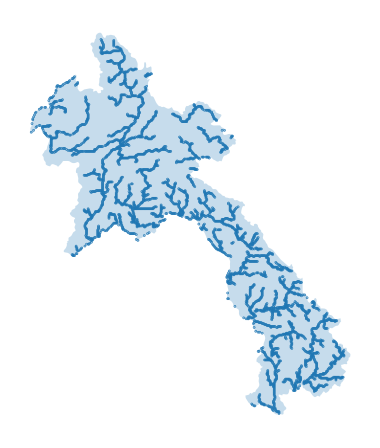

In [25]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=144)
world.query('ISO_A3 == "LAO" ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
laos_point_grid_extended[2018].query('distance_to_river < 1000').plot('is_island', ax=ax , markersize=0.1)
ax.set_xticks([])
ax.set_yticks([]);

[]

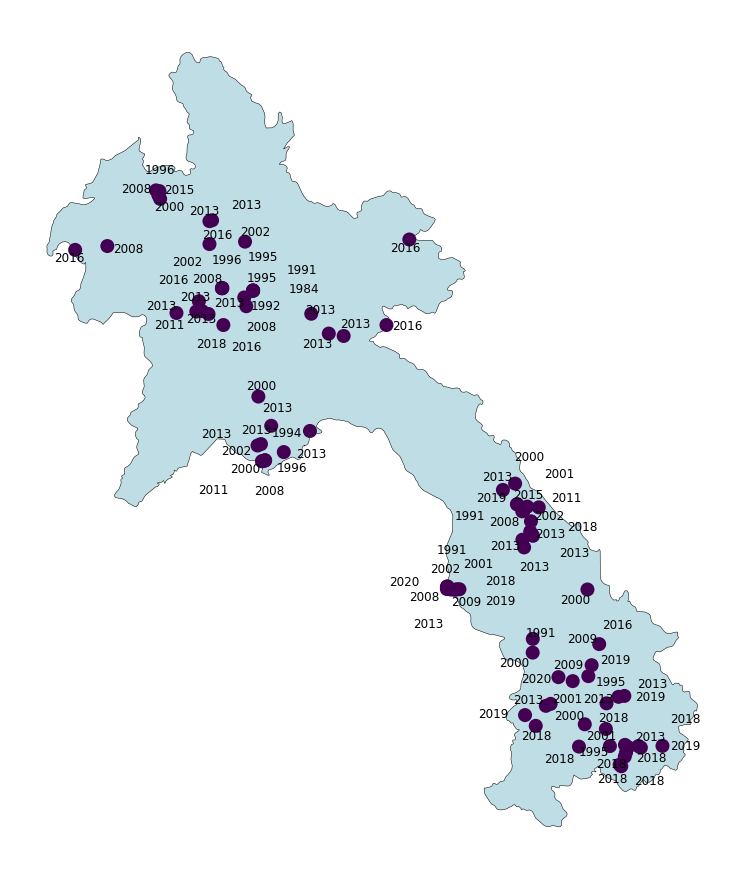

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(14, 6), dpi=144)

# Plot the map and disaster locations
world.query('ISO_A3 == "LAO"').plot(facecolor='#007896', alpha=0.25, ax=ax)
world.query('ISO_A3 == "LAO"').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
laos_disasters_geo.query('is_disaster == 1').plot('is_disaster', ax=ax)

texts = []
for idx, row in laos_disasters_geo.query('is_disaster == 1').iterrows():
    # Compute an angle for rotation (in radians)
    angle = np.random.uniform(0, 2 * np.pi)  # Random angle between 0 and 360 degrees

    # Define the label distance from the point
    r = 0.05  # Adjust this to control the distance from the point

    # Convert polar coordinates to Cartesian (offset x, y)
    dx = r * np.cos(angle)
    dy = r * np.sin(angle)

    texts.append(ax.annotate(row['Start_Year'].year, 
                             xy=(row.geometry.x, row.geometry.y),  # Point location
                             xytext=(row.geometry.x + dx, row.geometry.y + dy),  # Rotated position
                             textcoords="data",
                             fontsize=6, color='black',
                             ha='center', va='center'))  # Keep text aligned

# Adjust text positions slightly to avoid overlapping
adjust_text(texts, ax=ax, only_move={'text': 'xy'}, expand_text=(1.1, 1.1));
ax.set_xticks([])
ax.set_yticks([])

# fig.savefig(here('notebooks/final_paper/figures_and_plots/eda') / 'year_event_map_lao.png', format = 'png', bbox_inches='tight');

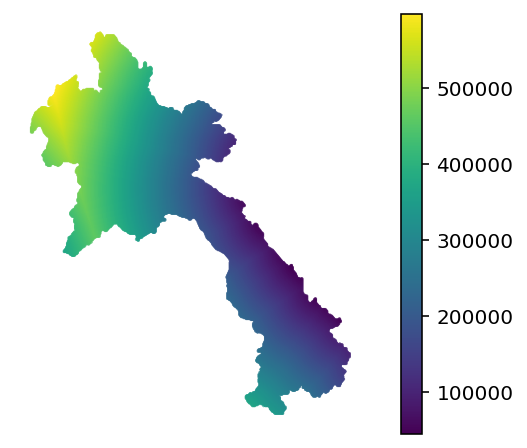

In [27]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=144)
world.query('ISO_A3 == "LAO" ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
laos_point_grid_extended[2018].plot('distance_to_coastline', ax=ax , markersize=0.1, legend = True)
ax.set_xticks([])
ax.set_yticks([]);



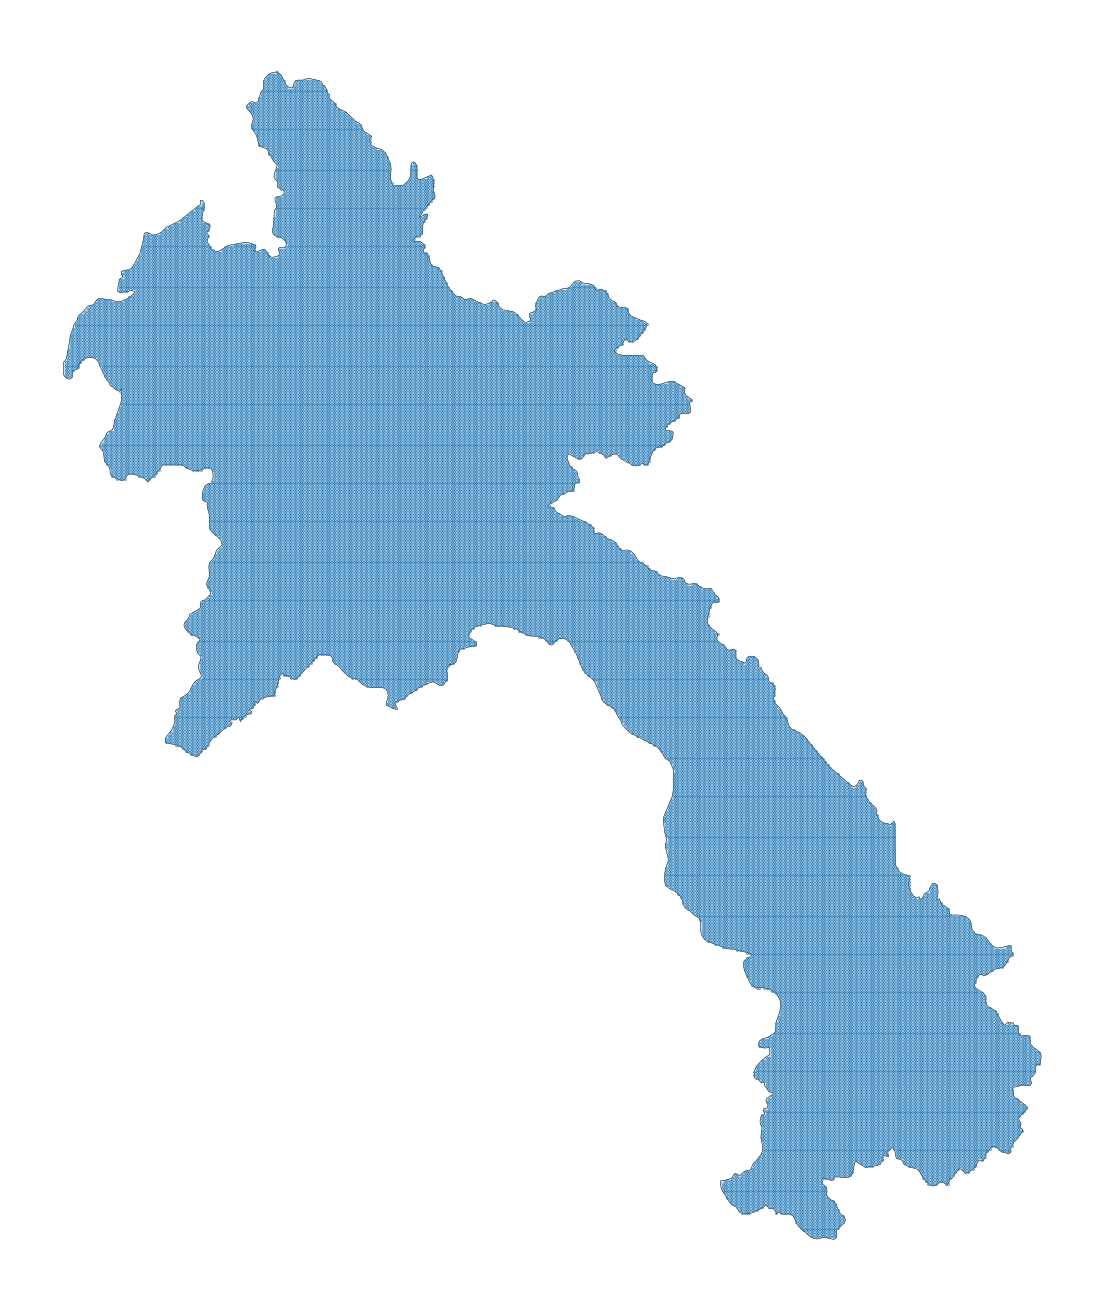

In [28]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
world.query('ISO_A3 == "LAO" ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
world.query('ISO_A3 == "LAO"').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)
laos_point_grid.plot( markersize=0.1, 
                                      ax=ax, )

ax.axis('off')
# plt.title("Synthetic vs. real data")
plt.show();

# Model on the SEA data set: HSGP component

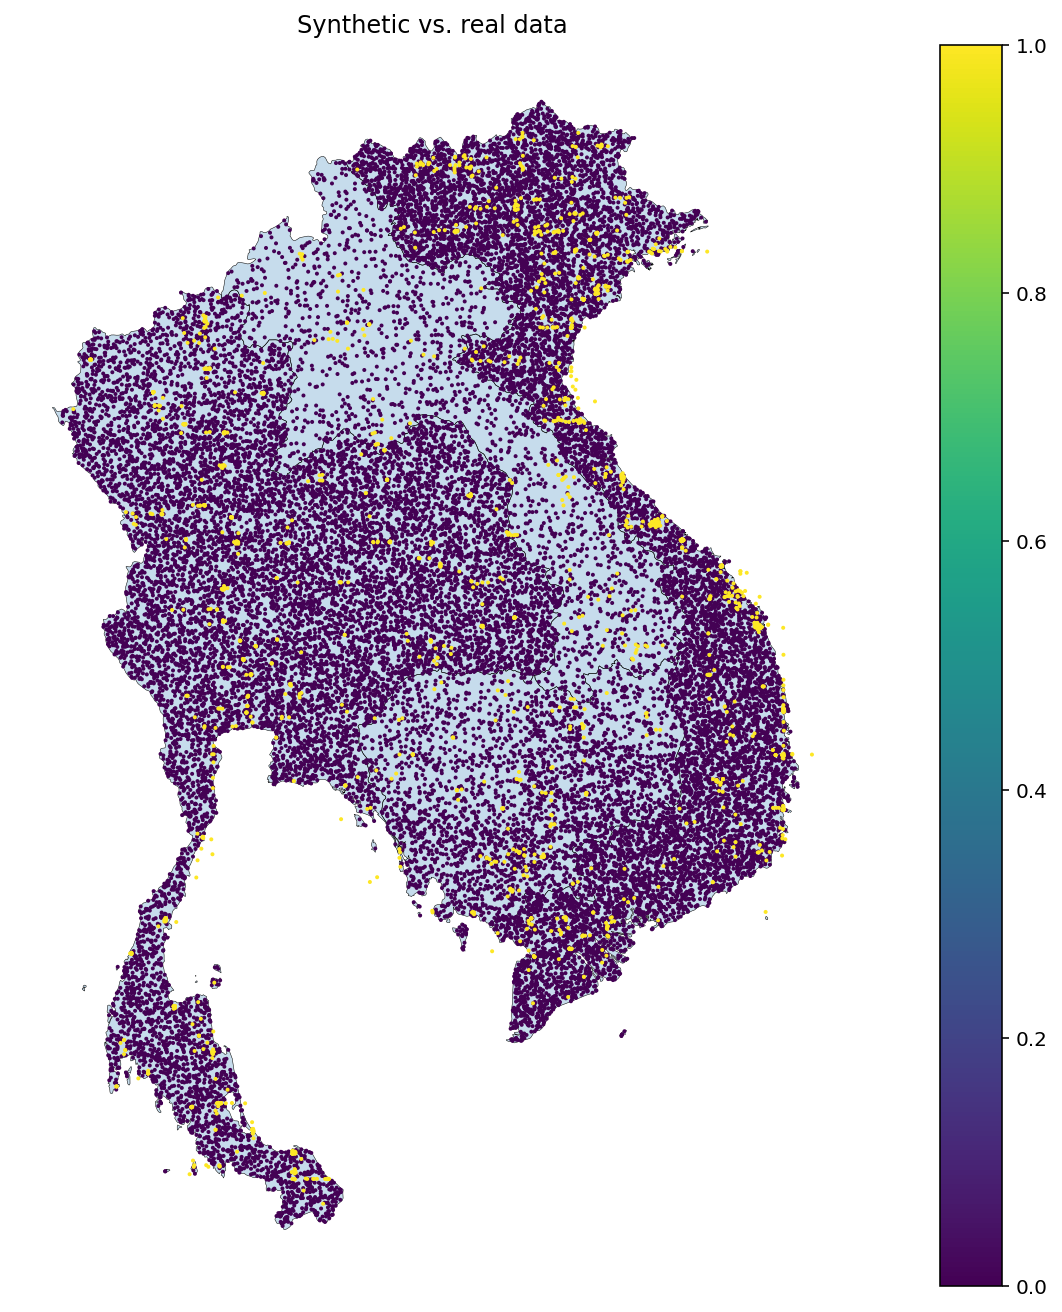

In [29]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
world.query('ISO_A3 in @laos_neighboors ').plot(facecolor='tab:blue', alpha=0.25, ax=ax)
world.query('ISO_A3 in @laos_neighboors').plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

sea_df.plot('is_disaster', 
                                      markersize=1, 
                                      ax=ax, 
                                      legend=True, 
                                      # categorical=True,
                                      cmap='viridis')
ax.axis('off')
plt.title("Synthetic vs. real data")
plt.show()

# HSGP model

In [30]:
#Define cooords
is_disaster_idx , is_disaster = pd.factorize(sea_df["is_disaster"])
ISO_idx, ISO = pd.factorize(sea_df["ISO"]) 
obs_idx = sea_df.index
gp_features = ["lat", "long"]

#Creating idx
xr_idx = xr.Coordinates.from_pandas_multiindex(sea_df.set_index(['ISO', 'Start_Year']).index, 'obs_idx')

#Set coords
coords_sea = {"is_disaster" : is_disaster,
        "obs_idx": obs_idx,
        "ISO": ISO,
        "feature": features_stand,
        "gp_feature":gp_features }

In [31]:
with pm.Model(coords=coords_sea) as model_sea_hsgp:
    #Declare data
    X, Y= add_data(features= features_stand ,  target = "is_disaster", df =  sea_df_stand, )

    # HSGP process
    X_gp = pm.Data("X_gp", sea_df_stand[["lat", "long"]])

    # Prior on the HSGP
    eta = pm.Exponential("eta", scale=2)
    ell_params = pm.find_constrained_prior(
        pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
    )
    ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

    m0, m1, c = 35, 35, 1.5
    gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)
    
    phi, sqrt_psd = gp.prior_linearized(X=X_gp)

    basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
    HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd))

    p = HSGP_component
    
    y_hat = pm.Bernoulli('y_hat', logit_p = p, observed=Y, dims='obs_idx')


C:\Users\camil\AppData\Local\Temp\ipykernel_91220\2324413867.py:10: FutureWarning: find_constrained_prior is deprecated and will be removed in a future version. Please use maxent function from PreliZ. https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.unidimensional.maxent
  ell_params = pm.find_constrained_prior(


In [32]:
# Sample the model
model_path = "idata/hsgp_lao.idata"
if exists(model_path):
    model_sea_hsgp_idata = az.from_netcdf(model_path)

else:
    compiled_model = nutpie.compile_pymc_model(freeze_dims_and_data(model_sea_hsgp), backend="jax", gradient_backend='jax')
    model_sea_hsgp_idata = nutpie.sample(compiled_model)
    #Save the idata
    az.to_netcdf(data = model_sea_hsgp_idata, filename= pathlib.Path(model_path))

In [33]:
hsgp_sum = az.summary(model_sea_hsgp_idata, var_names = ['ell_log__', 'eta', 'eta_log__'] )
hsgp_sum[['mean', 'sd', 'ess_bulk', 'ess_tail', 'r_hat']]

,mean,sd,ess_bulk,ess_tail,r_hat
ell_log__[0],-0.54,0.10,2027.00,2569.00,1.00
ell_log__[1],-0.62,0.08,2375.00,3180.00,1.00
eta,4.99,0.36,1376.00,2432.00,1.00
eta_log__,1.60,0.07,1376.00,2432.00,1.00


### Sea predictions

In [34]:
# We sample the predictions
file_name = 'idata/hsgp_lao.pkl'
if exists(file_name):
    with open(file_name, 'rb') as f:
        model_sea_hsgp_idata_plot = pickle.load(f)

else:
    with model_sea_hsgp.copy() as temp_model:
        pm.set_data({"X_gp": sea_point_grid[["lat", "long"]],
                     "Y": np.full(sea_df_stand.shape[0], 0 ),
                    },
                coords= {"obs_idx": sea_df_stand.index.values } 
               )
    
        HSGP_invlogit = pm.Deterministic('HSGP_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
    
    
    
    with freeze_dims_and_data(temp_model):
        model_sea_hsgp_idata_plot = pm.sample_posterior_predictive(model_sea_hsgp_idata, var_names=["HSGP_invlogit","HSGP_component"], 
                                                             compile_kwargs= {"mode" : "JAX" })
    with open(file_name, 'wb') as f:
        pickle.dump(model_sea_hsgp_idata_plot, f)

Sampling: []
INFO:pymc.sampling.forward:Sampling: []


Output()

In [35]:
# Create the geopandas version of the predictions
sea_hsgp_pred = prediction_to_gpd_df(prediction_idata = model_sea_hsgp_idata_plot , 
                     variables = ["HSGP_invlogit", "HSGP_component"] , 
                     points = sea_point_grid)

df_=  sea_hsgp_pred['HSGP_invlogit'].assign(norm_prob =  
                                                   (sea_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'] * 100 
                                                    /  sea_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'].sum()) )

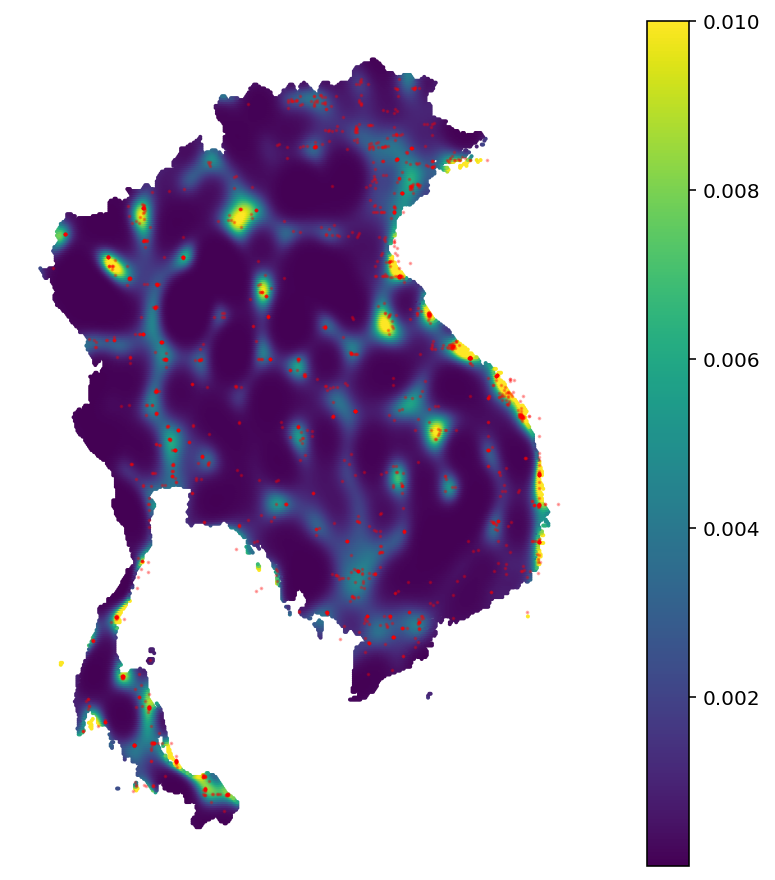

In [36]:
# Plot the predictions
fig, ax = plt.subplots(figsize=(10, 6), dpi= 144 )
df_.plot("norm_prob",legend=True, ax=ax,markersize =1 , vmax = 0.01)
sea_disasters_geo.plot(ax=ax, alpha = 0.3, c = "red",markersize =0.7, )

ax.set_xticks([])
ax.set_yticks([]);

# fig.savefig("figures_and_plots/results/event_HSGP_sea_pred.png",bbox_inches="tight",  )

## Laos predictions

In [37]:
# We sample the predictions
file_name = 'idata/hsgp_lao_2.pkl'
if exists(file_name):
    with open(file_name, 'rb') as f:
        hsgp_lao_pred = pickle.load(f)

else:

    # We sample the predictions
    with model_sea_hsgp.copy() as temp_model:
        pm.set_data({"X_gp": laos_point_grid[["lat", "long"]],
                     "X": laos_point_grid_extended[2018][features_stand],
                     "Y": np.full(laos_point_grid.shape[0], 0 ),
                     
                    },
                coords= {"obs_idx": laos_point_grid.index.values } 
               )
    
        HSGP_invlogit = pm.Deterministic('HSGP_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
    
    
    
    with freeze_dims_and_data(temp_model):
        hsgp_lao_pred = pm.sample_posterior_predictive(model_sea_hsgp_idata, var_names=["HSGP_invlogit","HSGP_component"], 
                                                             compile_kwargs= {"mode" : "JAX" })
    with open(file_name, 'wb') as f:
        pickle.dump(model_sea_hsgp_idata_plot, f)

In [38]:
# Create the geopandas version of the predictions
lao_hsgp_pred = prediction_to_gpd_df(prediction_idata = hsgp_lao_pred , 
                     variables = ["HSGP_invlogit", "HSGP_component"] , 
                     points = laos_point_grid[["lat", "long"]])

df_lao=  lao_hsgp_pred['HSGP_invlogit'].assign(norm_prob =  
                                                   (lao_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'] * 100 
                                                    /  lao_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'].sum()) )

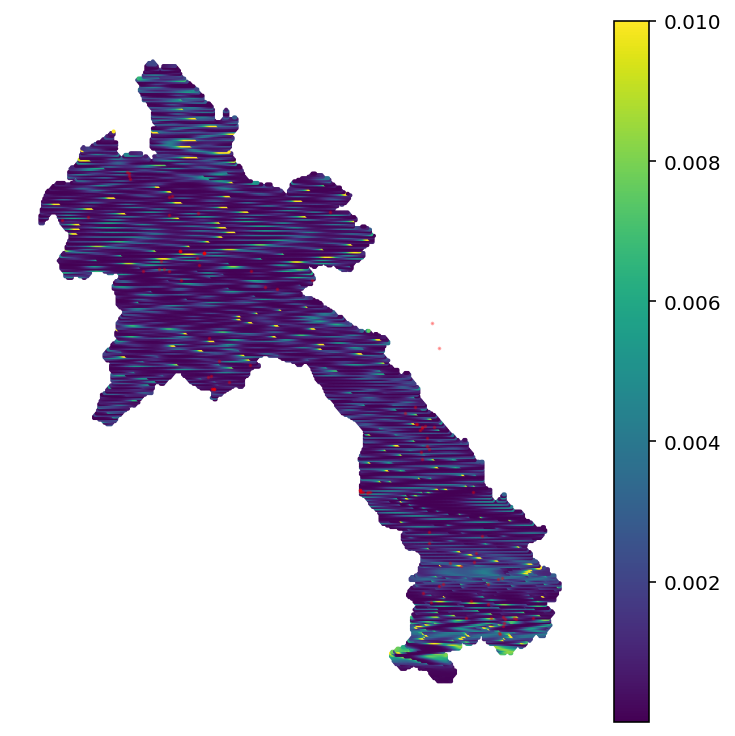

In [39]:
# Plot the predictions
fig, ax = plt.subplots(figsize=(5, 5), dpi= 144 )
df_lao.plot("norm_prob",legend=True, ax=ax,markersize =1,  vmax = 0.01 )
sea_disasters_geo.query('ISO == "LAO"').plot(ax=ax, alpha = 0.3, c = "red",markersize =0.7, )

ax.set_xticks([])
ax.set_yticks([]);

# fig.savefig("figures_and_plots/results/event_HSGP_lao_pred.png",bbox_inches="tight",)

# Model on the SEA data set: Full model

In [40]:
with pm.Model(coords=coords_sea) as model_sea_full:
    #Declare data
    X, Y= add_data(features= features_stand ,  target = "is_disaster", df =  sea_df_stand, )
    ISO_idx_pt = pm.Data("ISO_idx_pt", ISO_idx, dims= ["obs_idx"] )
    
    # # #Country effect
    country_effect = pm.Normal("country_effect", mu = 0, sigma =1, dims = ["ISO"])

    # #Betas
    beta_sigma = [0.1] * 8
    beta = pm.Normal("beta", mu = 0, sigma = beta_sigma, dims = ["feature"])

    # HSGP process
    X_gp = pm.Data("X_gp", sea_df[["lat", "long"]])

    # Prior on the HSGP
    eta = pm.Exponential("eta", scale=2)
    ell_params = pm.find_constrained_prior(
        pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
    )
    ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

    m0, m1, c = 35, 35, 1.5
    gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)

    phi, sqrt_psd = gp.prior_linearized(X=X_gp)

    basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
    HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd),dims= ["obs_idx"])


    #Model mu
    mu = pm.Deterministic("mu", 
                          country_effect[ISO_idx_pt] + 
                          X@beta +
                          HSGP_component , dims= ["obs_idx"] )
    

    # Now define the observed variable separately
    y_hat = pm.Bernoulli('y_hat', logit_p=mu, observed=Y, dims=['obs_idx'])

C:\Users\camil\AppData\Local\Temp\ipykernel_91220\303045251.py:18: FutureWarning: find_constrained_prior is deprecated and will be removed in a future version. Please use maxent function from PreliZ. https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.unidimensional.maxent
  ell_params = pm.find_constrained_prior(


In [41]:
# Sample the model
idata_full_path = "idata/sea_geo_model.idata"
if exists(idata_full_path):
    model_sea_full_idata = az.from_netcdf(idata_full_path)

else:
    compiled_model = nutpie.compile_pymc_model(freeze_dims_and_data(model_sea_full), backend="jax", gradient_backend='jax')
    model_sea_full_idata = nutpie.sample(compiled_model, chains = 8, draws = 1000, target_accept = 0.9)
    # Save the idata
    az.to_netcdf(data=model_sea_full_idata, filename=pathlib.Path(idata_full_path))

In [42]:
vars_ = ['ell_log__', 'eta', 'eta_log__','beta', 'country_effect']
full_sum = az.summary(model_sea_full_idata, var_names = vars_ )
full_sum[['mean', 'sd', 'ess_bulk', 'ess_tail', 'r_hat']]

,mean,sd,ess_bulk,ess_tail,r_hat
ell_log__[0],-1.37,0.25,3987.00,4003.00,1.00
ell_log__[1],-1.35,0.18,4197.00,4835.00,1.00
eta,3.12,0.36,2088.00,3751.00,1.00
eta_log__,1.13,0.11,2088.00,3751.00,1.00
beta[log_distance_to_river__standardized],-0.44,0.03,11561.00,5363.00,1.00
beta[log_distance_to_coastline__standardized],-0.17,0.06,7776.00,5073.00,1.00
beta[Population__standardized],0.10,0.09,14518.00,6600.00,1.00
beta[co2__standardized],0.25,0.06,13074.00,6135.00,1.00
beta[precip_deviation__standardized],0.33,0.03,8833.00,5334.00,1.00
beta[dev_ocean_temp__standardized],0.02,0.03,8344.00,4750.00,1.00


### SEA predictions

In [43]:
# full model SEA predictions

years_region = years_data.copy()
# Rebuild ISO_idx_sea
ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}

geo_full_sea_idata = {}

for year in years_region:
    ISO_idx_sea=  sea_point_grid_extended[year].ISO.map(ISO_to_idx.get)
    file_name = 'idata/geo_full_sea_'+str(year) +'.pkl'
    
    if exists(file_name):
        with open(file_name, 'rb') as f:
            geo_full_sea_idata[year] = pickle.load(f)
    else:
        with model_sea_full.copy() as temp_model:
            #Declare data
            pm.set_data({"X_gp":sea_point_grid_extended[year][["lat", "long"]],
                         "Y": np.full(sea_point_grid_extended[year].shape[0], 0 ),
                         "X": sea_point_grid_extended[year][features_stand],
                         "ISO_idx_pt": ISO_idx_sea
         
                    },
                coords= {"obs_idx": sea_point_grid_extended[year].index.values } 
               )
        
            y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))
    
            HSGP_component_invlogit = pm.Deterministic('HSGP_component_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
        
        
        
        with freeze_dims_and_data(temp_model):
            geo_full_sea_idata[year] = pm.sample_posterior_predictive(model_sea_full_idata, var_names=["y_hat_invlogit","y_hat", "HSGP_component",
                                                                                                          "HSGP_component_invlogit",], 
                                                         )
        with open(file_name, 'wb') as f:
            pickle.dump(geo_full_sea_idata[year], f)


Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

In [44]:
# Create the geopandas version of the predictions
model_sea_full_predictions_geo = {}

for year in years_region:
    model_sea_full_predictions_geo[year] = prediction_to_gpd_df(prediction_idata = geo_full_sea_idata[year] , 
                         variables = ['y_hat'] , 
                         points = sea_point_grid_extended[year] )

In [45]:
# Normalize the results
df_ = {}
for year in years_region:
    df_[year]= model_sea_full_predictions_geo[year]['y_hat'].assign(norm_prob =  
                                                   (model_sea_full_predictions_geo[year]['y_hat']['y_hat'] * 100 
                                                    /  model_sea_full_predictions_geo[year]['y_hat']['y_hat'].sum()) )

In [46]:
# Load the posterior with event frequency predictions
file_name = 'idata/idata_post_combined_1.pkl'

if exists(file_name):
    with open(file_name, 'rb') as f:
        idata_damage_curve_combined = pickle.load(f)

idata_damage_curve_sea = idata_damage_curve_combined.sel(ISO =laos_neighboors)

In [47]:
# Multiply by the predicted intensity
for year in years_region:
    freq_dict = (idata_damage_curve_sea.posterior_predictive['y_hat_n_events'].mean(dim = ['chain', 'draw'])
                 .to_dataframe().query('obs_year == @year & obs_iso in @laos_neighboors').reset_index(drop=True)
                 [['obs_iso', 'y_hat_n_events']]).set_index('obs_iso').to_dict()['y_hat_n_events']
    
    df_[year]['event_freq_pred'] = df_[year]['ISO'].map(freq_dict)
    
    df_[year] = df_[year].assign(
        yhat_freq = df_[year]['norm_prob'] * df_[year]['event_freq_pred'])

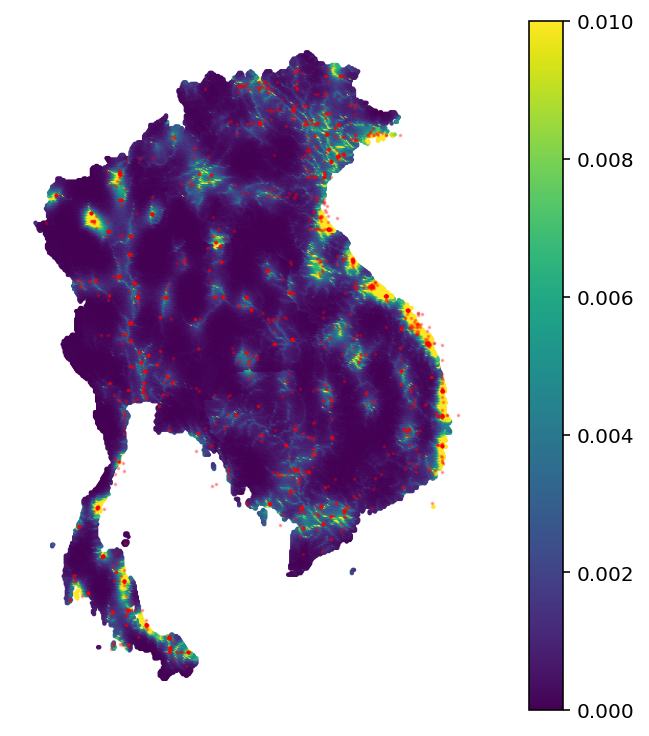

In [48]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(8, 5), dpi= 144 )
df_[2018].plot("norm_prob",legend=True, ax=ax,markersize =1.5, vmax =  0.01  )
sea_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =0.7, )
# plt.title("Event probability for Laos neighbors", );


ax.set_xticks([])
ax.set_yticks([]);
# fig.savefig("figures_and_plots/results/full_model_sea_2018.png",  bbox_inches="tight",);

In [49]:
df_[2018]['yhat_freq'].max()

0.38465735388534217

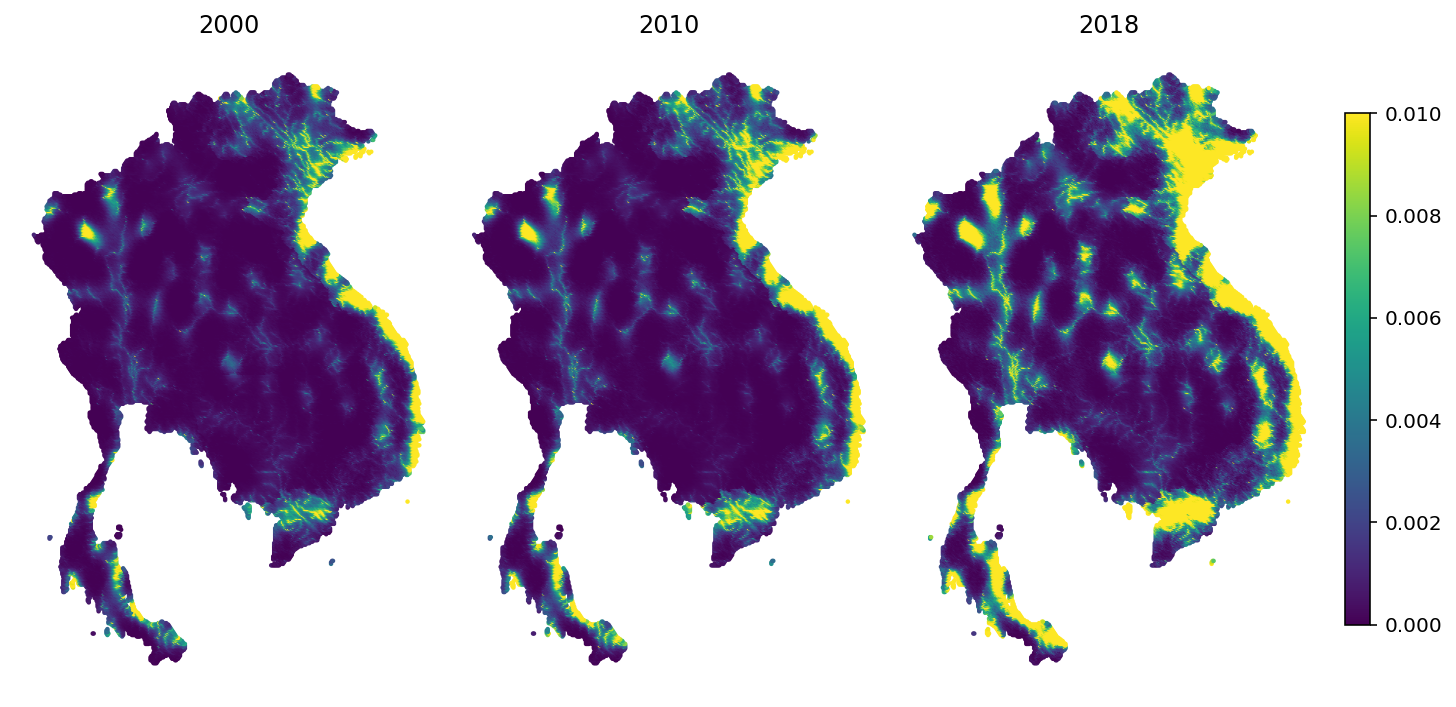

In [50]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )
axes = axes.flatten()

years_plot= years_region.copy()

legen_list = [ False, False, True]

vmax = [0.03, 0.020, 0.01]

for year, n in zip(years_plot, range(0,3) ):
    df_[year].plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = vmax[n],  legend_kwds={
                                                         "shrink":  0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                } )

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
# fig.savefig("figures_and_plots/results/full_model_yearly_lao.png",  bbox_inches="tight",);

In [51]:
laos_neighboors

['KHM', 'THA', 'LAO', 'VNM']

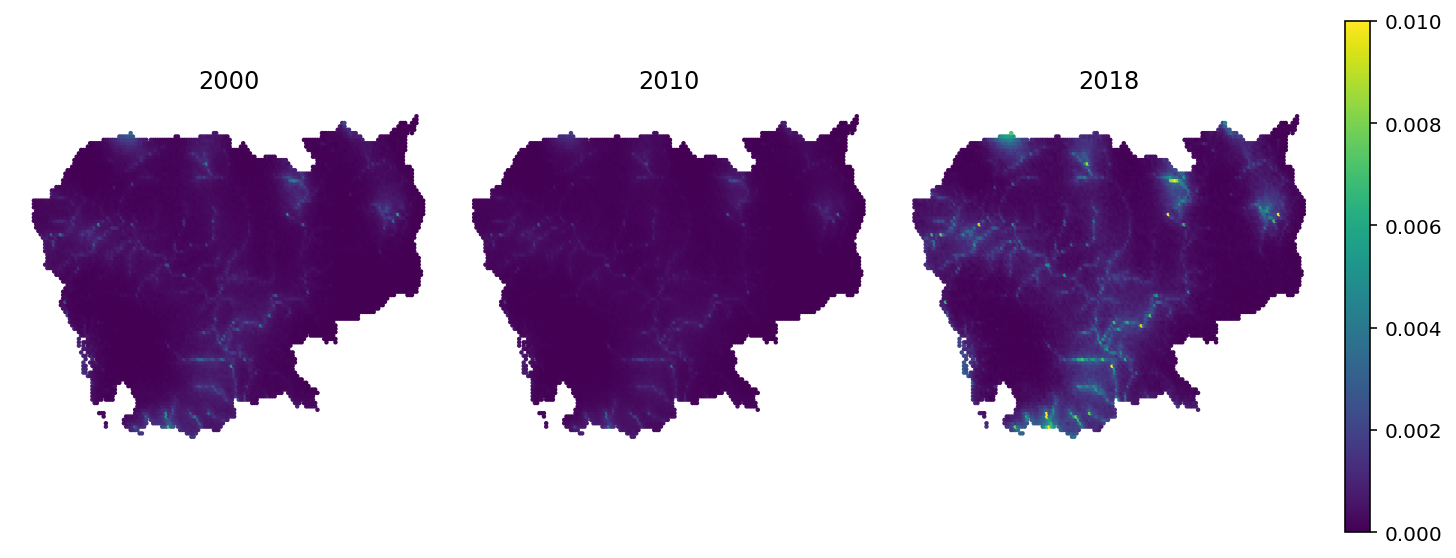

In [52]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )
axes = axes.flatten()

years_plot= years_region.copy()

legen_list = [ False, False, True]

vmax = [0.03, 0.020, 0.01]
iso = 'KHM'

for year, n in zip(years_plot, range(0,3) ):
    df = df_[year].query('ISO == @iso')
    df.plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = vmax[n],  legend_kwds={
                                                         "shrink":  0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                } )

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
# fig.savefig("figures_and_plots/results/full_model_yearly_lao.png",  bbox_inches="tight",);

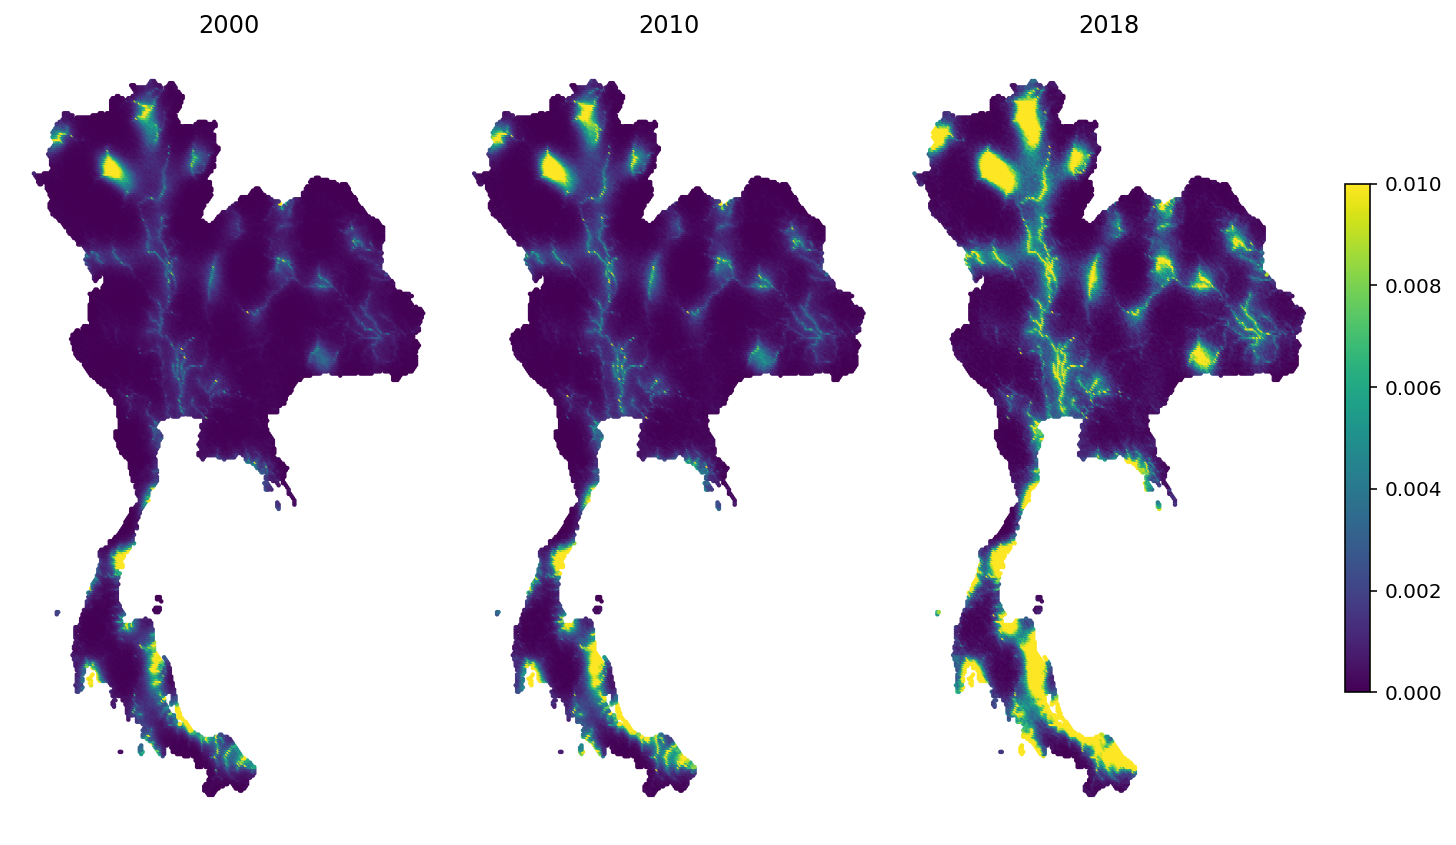

In [53]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )
axes = axes.flatten()

years_plot= years_region.copy()

legen_list = [ False, False, True]

vmax = [0.03, 0.020, 0.01]
iso = 'THA'

for year, n in zip(years_plot, range(0,3) ):
    df = df_[year].query('ISO == @iso')
    df.plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = vmax[n],  legend_kwds={
                                                         "shrink":  0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                } )

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
# fig.savefig("figures_and_plots/results/full_model_yearly_lao.png",  bbox_inches="tight",);

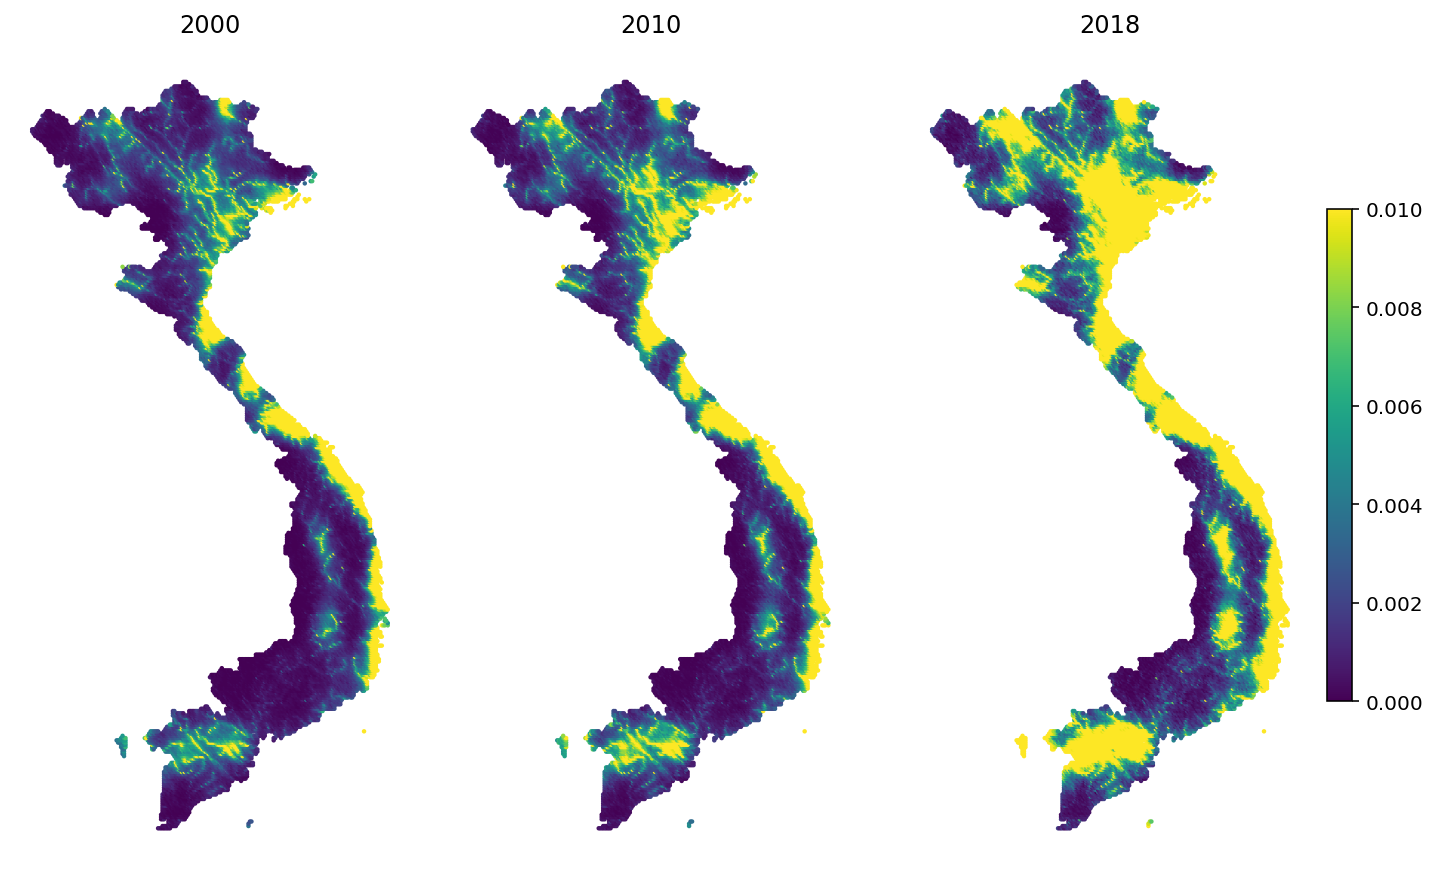

In [54]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )
axes = axes.flatten()

years_plot= years_region.copy()

legen_list = [ False, False, True]

vmax = [0.03, 0.020, 0.01]
iso = 'VNM'

for year, n in zip(years_plot, range(0,3) ):
    df = df_[year].query('ISO == @iso')
    df.plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = vmax[n],  legend_kwds={
                                                         "shrink":  0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                } )

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
# fig.savefig("figures_and_plots/results/full_model_yearly_lao.png",  bbox_inches="tight",);

### Laos predictions

In [55]:
# Exclude point outside Lao
laos_disasters_geo= laos_disasters_geo.query('log_distance_to_coastline > 4')

In [56]:
# full model SEA predictions
result_years = [2000, 2010, 2018, 2030, 2045]
# Rebuild ISO_idx_sea
ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
geo_full_sea_idata_laos = {}

for year in result_years:
    file_name = 'idata/geo_full_lao_' + str(year) + '.pkl'
    ISO_idx_laos =  laos_point_grid_extended[year].ISO.map(ISO_to_idx.get)
    
    if exists(file_name):
        with open(file_name, 'rb') as f:
            geo_full_sea_idata_laos[year] = pickle.load(f)
            
    else:
        with model_sea_full.copy() as temp_model:
            #Declare data
            pm.set_data({"X_gp": laos_point_grid[["lat", "long"]],
                         "Y": np.full(laos_point_grid_extended[year].shape[0], 0 ),
                         "X": laos_point_grid_extended[year][features_stand],
                         "ISO_idx_pt": ISO_idx_laos
         
                    },
                coords= {"obs_idx": laos_point_grid_extended[year].index.values } 
               )
        
            y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))
    
            # River effect
            river_effect = pm.Deterministic('river_effect', temp_model["beta"][0] * laos_point_grid_extended[year]['log_distance_to_river__standardized'])
            # Coast effect
            coast_effect = pm.Deterministic('coast_effect',  temp_model["beta"][1] * laos_point_grid_extended[year]['log_distance_to_coastline__standardized'])
                                                    
        
        with freeze_dims_and_data(temp_model):
            geo_full_sea_idata_laos[year] = pm.sample_posterior_predictive(
                model_sea_full_idata, var_names=["y_hat_invlogit","HSGP_component", "y_hat", "river_effect", "coast_effect"], 
            
                                                             )
        with open(file_name, 'wb') as f:
            pickle.dump(geo_full_sea_idata_laos[year], f)


Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

Now we load the prediction of the frequency model to have the full event probability

In [57]:
# select LAO
idata_damage_curve_combined = idata_damage_curve_combined.posterior_predictive.sel(disaster = 'hydro', obs_iso = 'LAO')['y_hat_n_events'].mean(dim = ['chain', 'draw'])

In [58]:
# Create the geopandas version of the predictions
model_sea_full_predictions_geo_laos = {}

for year in result_years:
    model_sea_full_predictions_geo_laos[year] = prediction_to_gpd_df(prediction_idata = geo_full_sea_idata_laos[year] , 
                         variables = ['y_hat', "HSGP_component", "river_effect",'coast_effect'] , 
                         points = laos_point_grid_extended[year] )

In [59]:
# Normalized values
var_list = ['y_hat',]
for year in result_years:
    for var in var_list:
        model_sea_full_predictions_geo_laos[year][var] = model_sea_full_predictions_geo_laos[year][var].assign(norm = model_sea_full_predictions_geo_laos[year][var][var] *100 
                                                                / model_sea_full_predictions_geo_laos[year][var][var].sum(), )
# Multiply by the frequency predictions
for year in result_years:
    freq_pred = idata_damage_curve_combined.sel(obs_year = pd.to_datetime(str(year))).values
    
    model_sea_full_predictions_geo_laos[year]['y_hat'] = model_sea_full_predictions_geo_laos[year]['y_hat'].assign(
        yhat_freq = model_sea_full_predictions_geo_laos[year]['y_hat']['norm'] *freq_pred , inplace =True)


In [60]:
# We decompose further the effect for 2018
for var in ["HSGP_component", "river_effect",'coast_effect']:
    freq_pred = idata_damage_curve_combined.sel(obs_year = pd.to_datetime(str(year))).values
    model_sea_full_predictions_geo_laos[2018][var] = model_sea_full_predictions_geo_laos[2018][var].assign(norm = model_sea_full_predictions_geo_laos[2018][var][var] *100 
                                                            / model_sea_full_predictions_geo_laos[2018]['y_hat']['y_hat'].sum(), )
    
    model_sea_full_predictions_geo_laos[2018][var] = model_sea_full_predictions_geo_laos[2018][var].assign(
    propor_decomp = model_sea_full_predictions_geo_laos[2018][var]['norm'] *freq_pred , inplace =True)


[]

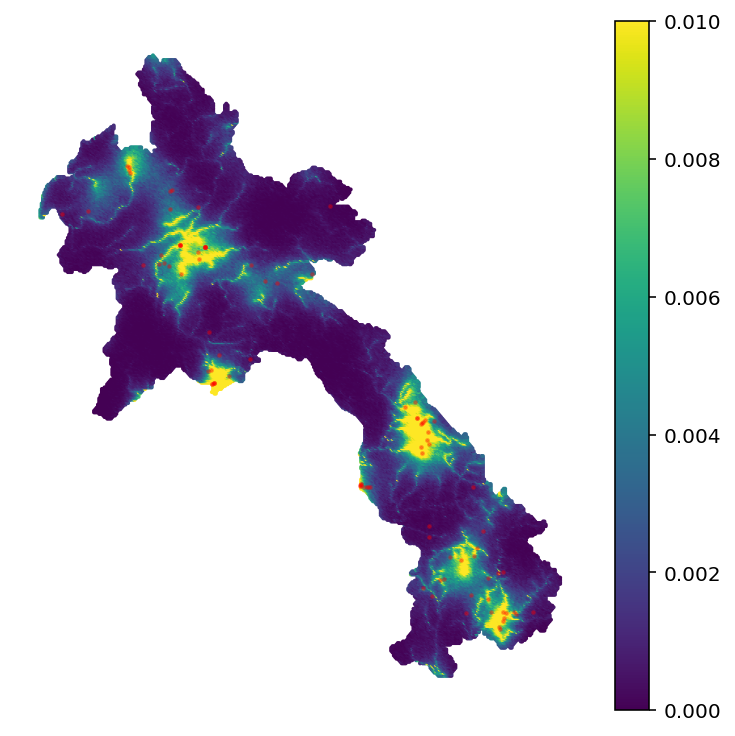

In [61]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(5, 5), dpi= 144 )
model_sea_full_predictions_geo_laos[2018]['y_hat'].plot("norm",legend=True, ax=ax,markersize =1, vmax = 0.01,)
laos_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =2, )
# plt.title("Event probability for Laos", )

ax.set_xticks([])
ax.set_yticks([])
# fig.savefig("figures_and_plots/results/full_model_lao_2018.png", bbox_inches="tight",);

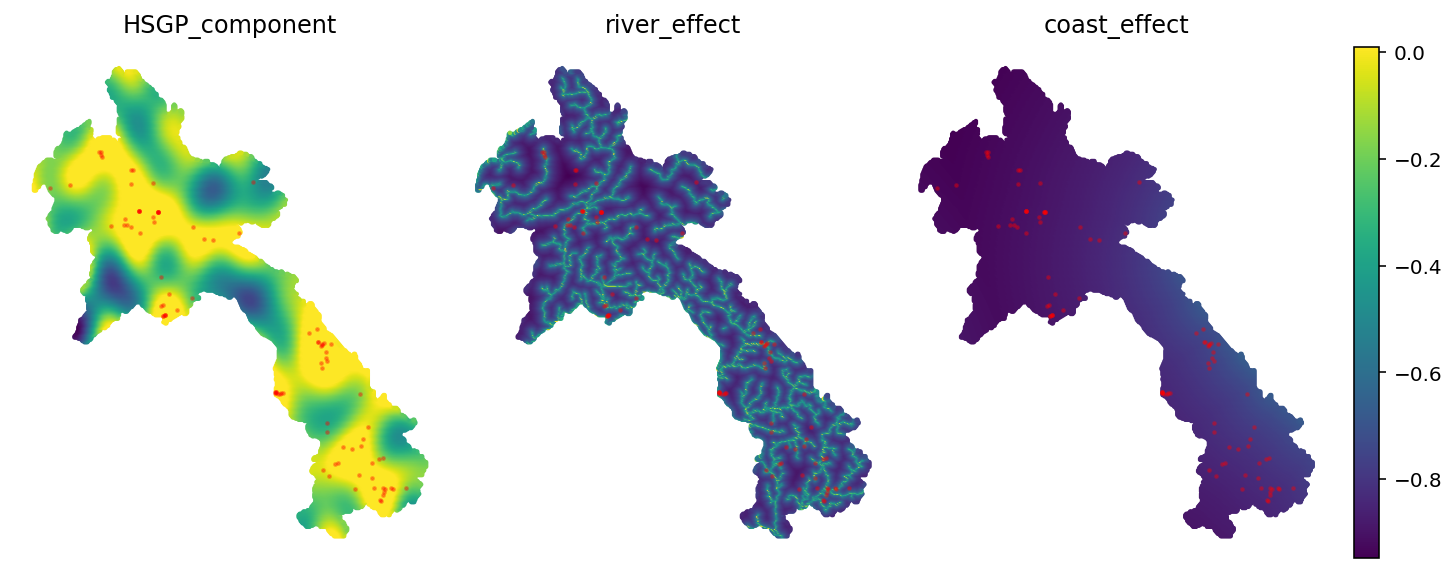

In [62]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )

var_list = ["HSGP_component", "river_effect",'coast_effect']
legen_list = [False, False, True]

for var, n in zip(var_list, [0,1,2] ):
    model_sea_full_predictions_geo_laos[2018][var].plot('propor_decomp',legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = 0.01,
                                                                                                       legend_kwds={
                                                         "shrink": 0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                })

    laos_disasters_geo.plot(ax= axes[n], alpha = 0.3, c = "r", markersize =2, )
    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(var)
    
# fig.savefig("figures_and_plots/results/decomposed_effect_lao.png",  bbox_inches="tight",);

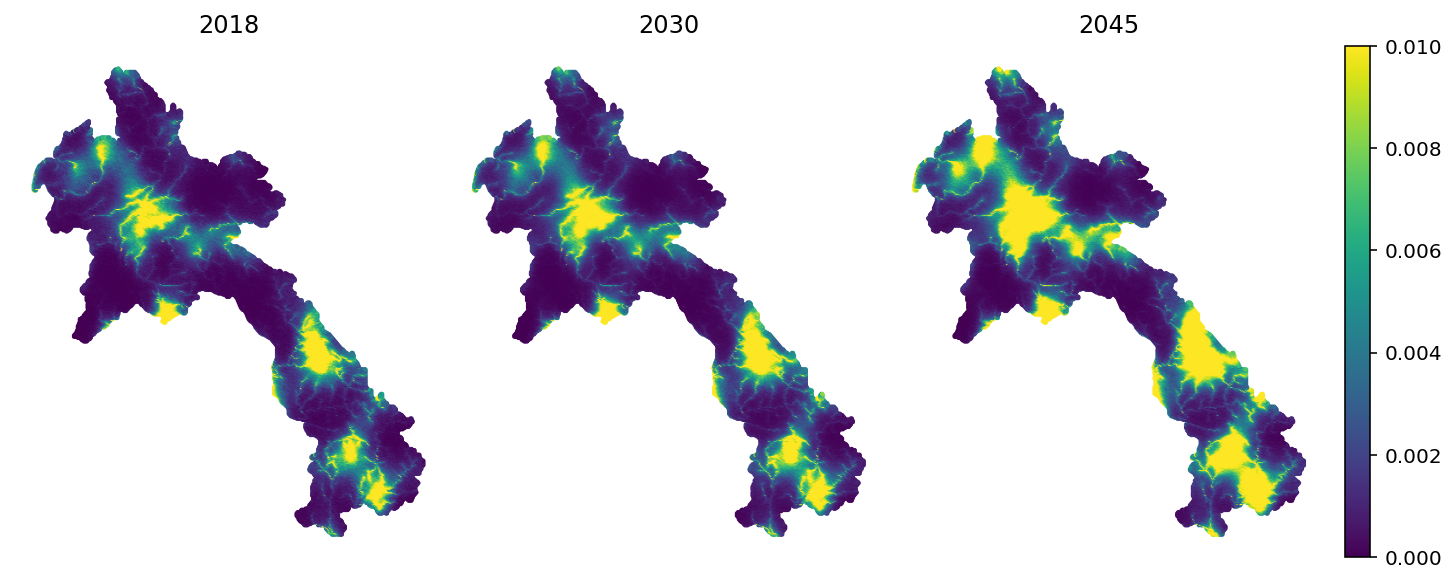

In [63]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )
axes = axes.flatten()

years_plot= [2018, 2030, 2045]

legen_list = [ False, False, True]

for year, n in zip(years_plot, range(0,3) ):
    model_sea_full_predictions_geo_laos[year]['y_hat'].plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = 0.01,  legend_kwds={
                                                         "shrink":  0.6,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                } )

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
# fig.savefig("figures_and_plots/results/full_model_yearly_lao.png",  bbox_inches="tight",);